https://www.youtube.com/watch?v=kJXUUO5M4ok

https://www.youtube.com/watch?v=bWsA2R707BM

## 1. Setting Up the Notebook

Run this cell to set up the notebook with appropriate packages. You may need to dowload and install these packages on your computer before doing so. 

In [1]:
import seaborn as sns
import csv
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import pylab 
import scipy.stats as stats
import gmaps 
import gmaps.datasets 

from IPython.display import display, Latex, Markdown

In [2]:
# Default plot configurations
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (20.0, 10.0)
sns.set()

## 2. Download the Data

Download the appropriate data and make sure to unzip it. The resulting, unzipped file folder should be put in the same location (directory) as this notebook (.ipynb) file.

## 3. Read In the Data

Run this cell to upload the SHP file into the notebook and store it as a GeoDataFrame, which is a DataFrame witha 'geometry' column.

In [3]:
# Set the Filepath
file_path = "data/pirapo_11_algodao_clip/pirapo_11_algodao_clip.shp"

# Read the Data
data = gpd.read_file(file_path)

Run this cell to see how much data we are dealing with.

In [4]:
shape = data.shape
print("Our GeoDataFrame contains " + str(shape[0]) + " data points, each with " + str(shape[1]) + " features associated with it.")

Our GeoDataFrame contains 154149 data points, each with 13 features associated with it.


There are over a hundred thousand data points in this collection, each with information on 13 unique features. Let's see what those variables are.

In [5]:
#Column labels
data.columns

Index([  u'DISTANCE', u'SWATHWIDTH', u'VRYIELDBAL',  u'SECTIONID',
             u'Crop',    u'WetMass',   u'Moisture',       u'Time',
          u'Heading',    u'VARIETY',  u'Elevation',    u'IsoTime',
         u'geometry'],
      dtype='object')

To avoid crashing our terminal, let's just look at the first few rows of our new GeoDataFrame.

In [6]:
data.head()

,DISTANCE,SWATHWIDTH,VRYIELDBAL,SECTIONID,Crop,WetMass,Moisture,Time,Heading,VARIETY,Elevation,IsoTime,geometry
0,1.250782,1.524,4.811164,1458,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.19998886071195 -13.83705880575909 0)
1,1.250782,1.524,4.811164,1459,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.20000168781748 -13.83706453203675 0)
2,1.250782,1.524,4.811164,1460,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.20001451492361 -13.83707025831374 0)
3,1.270782,1.524,28.514902,1458,175,6208.245947,99.999992,8/8/2018 10:19:39 PM,156.418422,algodao,550.021629,2018-08-08T22:19:39.389Z,POINT Z (-57.19998405642441 -13.8370695107892 0)
4,1.270782,1.524,28.514902,1459,175,6208.245947,99.999992,8/8/2018 10:19:39 PM,156.418422,algodao,550.021629,2018-08-08T22:19:39.389Z,POINT Z (-57.19999698581748 -13.83707501303677 0)


For those variables that are quantitative, we can get more information on them as it they pertain to our entire dataset.

In [32]:
data.describe()

,DISTANCE,SWATHWIDTH,VRYIELDBAL,SECTIONID,Crop,WetMass,Moisture,Heading,Elevation
count,154149.000000,1.541490e+05,154149.000000,154149.000000,154149.0,154149.000000,1.541490e+05,154149.000000,154149.000000
mean,2.133455,1.524000e+00,18.627771,1094.930210,175.0,4055.639096,9.999999e+01,240.718783,552.905994
std,0.277460,3.264510e-12,19.812481,478.347068,0.0,4313.584463,5.498198e-11,91.326034,1.464639
min,-0.001015,1.524000e+00,0.241720,580.000000,175.0,52.630958,9.999999e+01,1.126242,549.386566
25%,2.138985,1.524000e+00,16.328899,715.000000,175.0,3555.152498,9.999999e+01,154.661235,551.677902
50%,2.213909,1.524000e+00,18.223134,717.000000,175.0,3967.508454,9.999999e+01,155.681219,553.130902
75%,2.259129,1.524000e+00,20.086079,1621.000000,175.0,4373.136868,9.999999e+01,334.691875,554.140055
max,3.929218,1.524000e+00,2220.134205,2169.000000,175.0,483374.696737,9.999999e+01,358.539032,555.569902


## 4. Data Cleaning

Let's take a look at our main GeoDataFrame again.

In [33]:
data.head()

,DISTANCE,SWATHWIDTH,VRYIELDBAL,SECTIONID,Crop,WetMass,Moisture,Time,Heading,VARIETY,Elevation,IsoTime,geometry
0,1.250782,1.524,4.811164,1458,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.19998886071195 -13.83705880575909 0)
1,1.250782,1.524,4.811164,1459,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.20000168781748 -13.83706453203675 0)
2,1.250782,1.524,4.811164,1460,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.20001451492361 -13.83707025831374 0)
3,1.270782,1.524,28.514902,1458,175,6208.245947,99.999992,8/8/2018 10:19:39 PM,156.418422,algodao,550.021629,2018-08-08T22:19:39.389Z,POINT Z (-57.19998405642441 -13.8370695107892 0)
4,1.270782,1.524,28.514902,1459,175,6208.245947,99.999992,8/8/2018 10:19:39 PM,156.418422,algodao,550.021629,2018-08-08T22:19:39.389Z,POINT Z (-57.19999698581748 -13.83707501303677 0)


Looking at our main GeoDataFrame, each corresponding entry in the 'Time' and 'IsoTime' columns are the same. It might be more efficient to only keep one of these columns. Additionally, the times are in unicode format. We can convert each entry from a unicode timestamp to a datetime timestamp format, which might make our future analysis more efficient.

In [34]:
#Drop one of the columns
#data = data.drop('Time', axis=1)

#Import the datetime module
#from datetime import datetime

#Store the 'Time' column in a seperate array
#original_time = data['IsoTime']

#Apply a datetime transformation to each entry
#new_time = [datetime.strptime(time, '%Y-%m-%dT%H:%M:%S.%fZ') for time in original_time]

#Assign the 'IsoTime' column to the new array
#data['IsoTime'] = new_time

## 5. Plot the Data

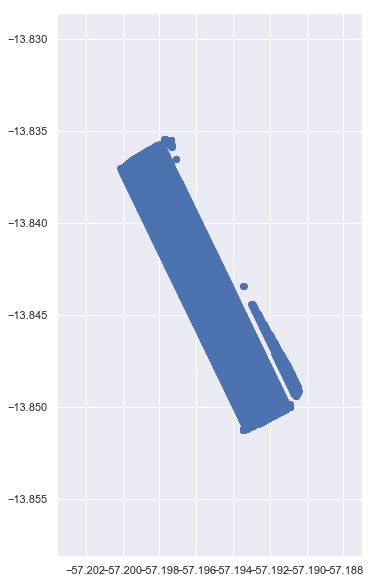

In [35]:
data.plot()

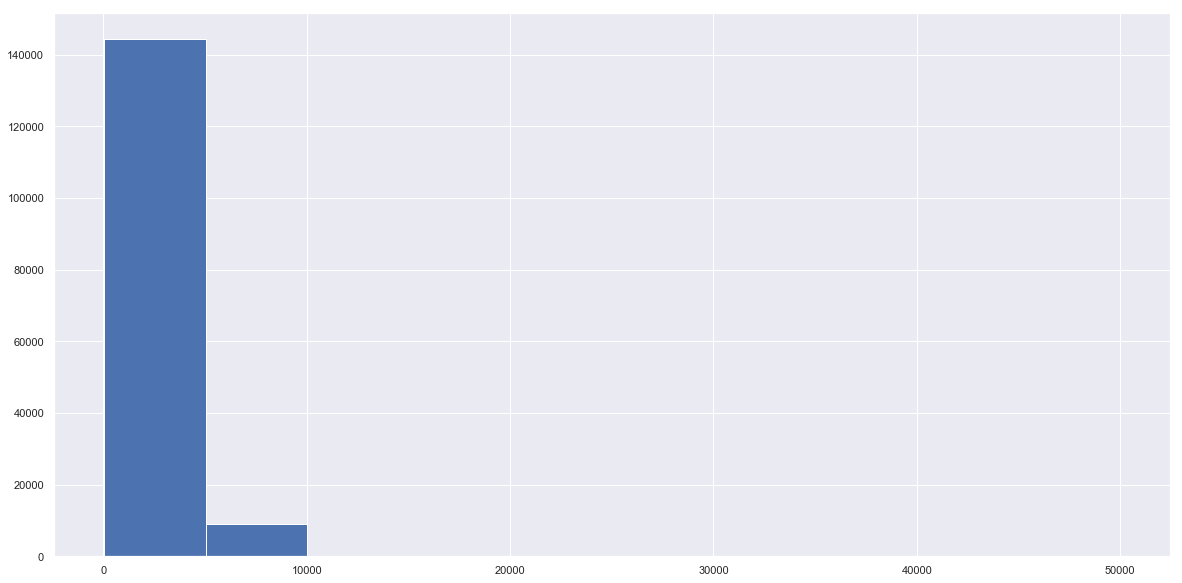

In [36]:
below_7000 = data[data['WetMass'] < 50000]['WetMass']
below_7000.hist()

In [37]:
data['WetMass'].value_counts()

3497.145042    27
3784.163349    27
3959.224160    27
3891.031867    24
4094.590950    24
3748.540509    24
3620.298287    24
4049.742501    24
4167.518088    24
3803.501462    24
3662.027899    21
3542.983872    21
3912.819171    21
3398.838973    21
3925.636911    21
3877.523726    21
4158.843464    21
4152.072109    21
3732.255783    21
3584.050807    21
4179.206186    21
3494.091656    21
4017.238499    21
4139.297479    21
3590.782220    21
3741.415941    21
3957.188569    21
3767.878622    21
4065.188480    21
4339.354599    21
               ..
4677.023976     3
4086.119459     3
4298.150033     3
2195.728481     3
4401.356774     3
4259.910371     3
3897.708494     3
5247.095855     3
3755.023255     3
3654.202420     3
4336.284299     3
799.726658      3
4022.087009     3
4185.311203     3
3857.778774     3
4180.640616     3
4014.563546     3
4348.404463     3
3672.090938     3
3323.429981     3
3827.715023     3
4297.433229     3
3456.807023     3
3791.758597     3
4098.76111

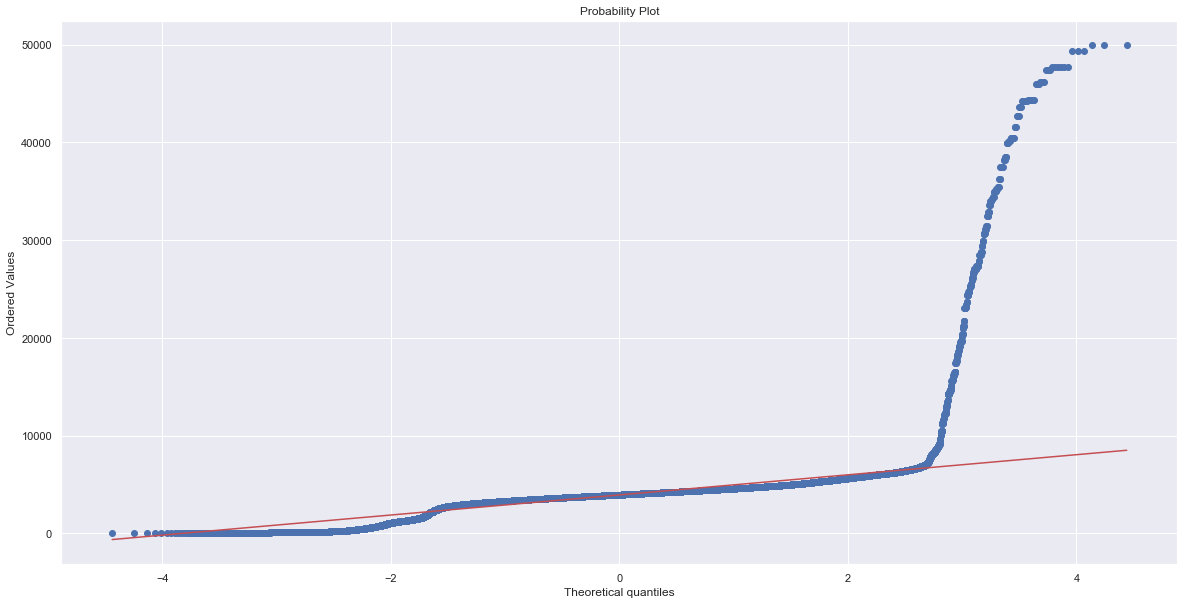

In [38]:
#Compares how our data lines up with normally distributed data.
#If all points have a perfectly normal distribution, all points would fall on the 45° line. 
#In our case, the data does not quite follow a straight line.
stats.probplot(below_7000, dist="norm", plot=pylab)
pylab.show()

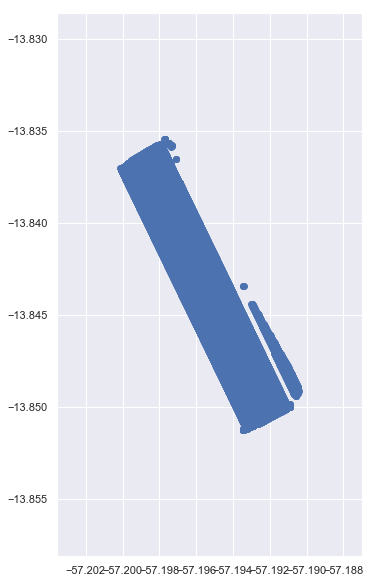

In [39]:
data[data['WetMass'] < 7000].plot()

Let's make a function that filters out data points depending on their WetMass level.

In [40]:
def wetmass_below(df, num):
    """Returns a new GeoDataFrame containing only
    rows/data points that have a WetMass below a certain level.
    
    NOTE: DOES NOT MODIFY ORIGINAL DATAFRAME, ONLY RETURNS A NEW ONE.
    
    Parameters
    ----------
    df : GeoDataFrame with 'geometry' and 'WetMass' columns.
    num : Number corresponding to the minimum WetMass level
        of points to discard.
    """
    return df[df['WetMass'] < num]

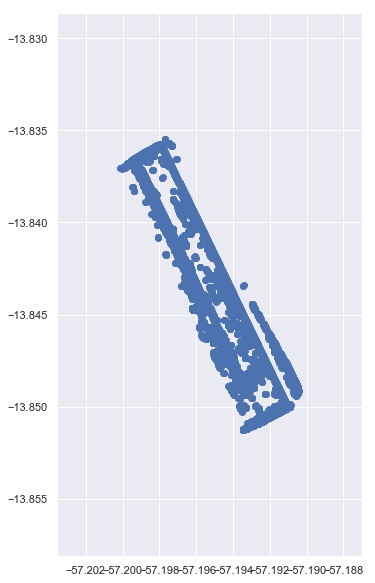

In [41]:
clean_data = wetmass_below(data, 3000)
clean_data.plot()

Let's make a function that plots the points with color to distinguish the differences according to some variable.

In [42]:
def plot_attribute(df, column, color="viridis_r"):
    """
    Plot the specific values from a column of a GeoDataFrame.

    Parameters
    ----------
    df : GeoDataFrame with a 'geometry' column.
    column : Single label of the column to display 
            the values for each data point.
    color : Single label of matplotlib color map.
            Default is 'viridis_r'
    """
    f, ax = plt.subplots(1, figsize=(12, 12))
    df.plot(ax=ax, column=column, cmap=color, legend=True)

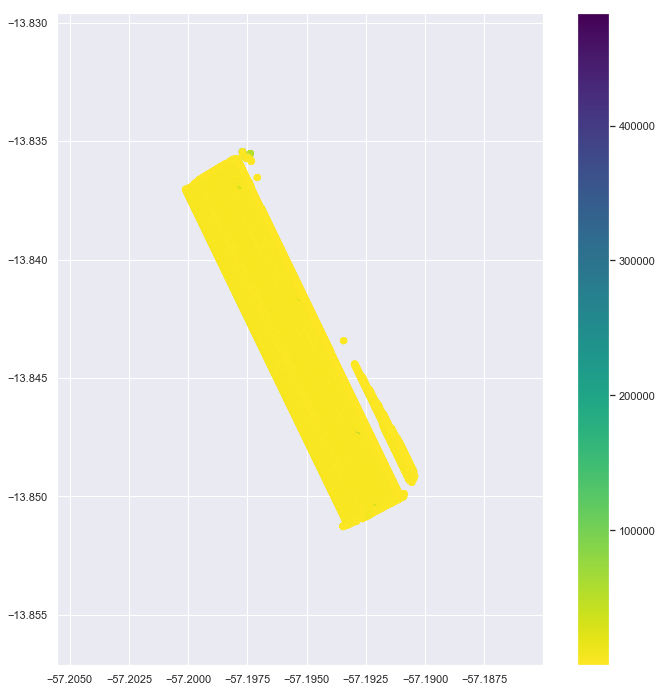

In [43]:
#Plots the differences in WetMass among all points in the dataset
plot_attribute(data, 'WetMass')

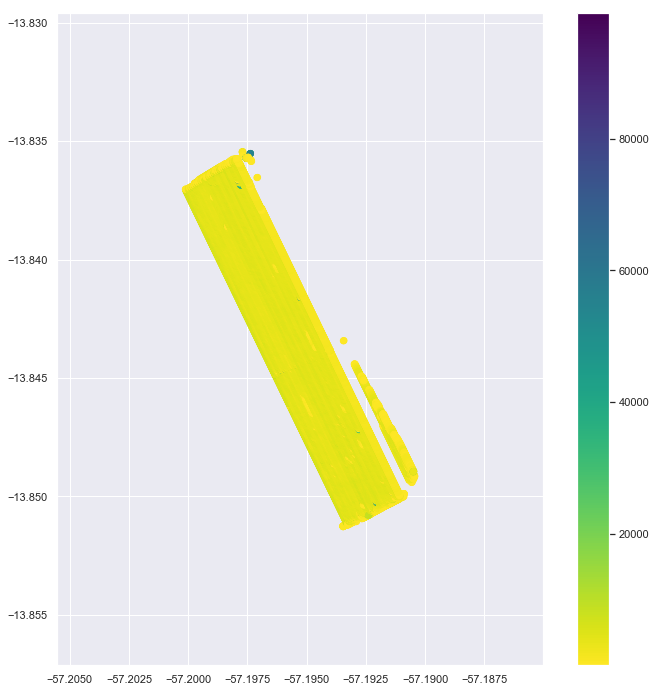

In [44]:
#Plots the differences in WetMass for all data points with WetMass below 3000
below_3000 = wetmass_below(data, 100000)
plot_attribute(below_3000, 'WetMass')

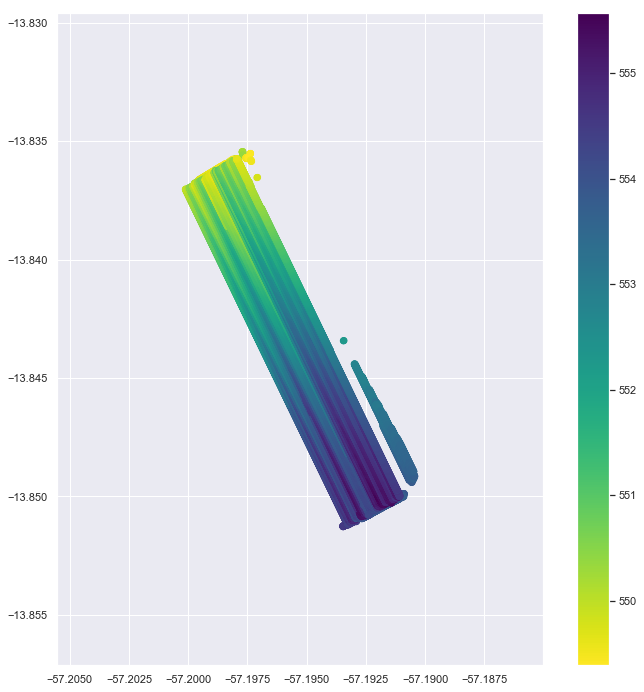

In [45]:
#Plots the differences in elevation among all points
plot_attribute(data, 'Elevation')

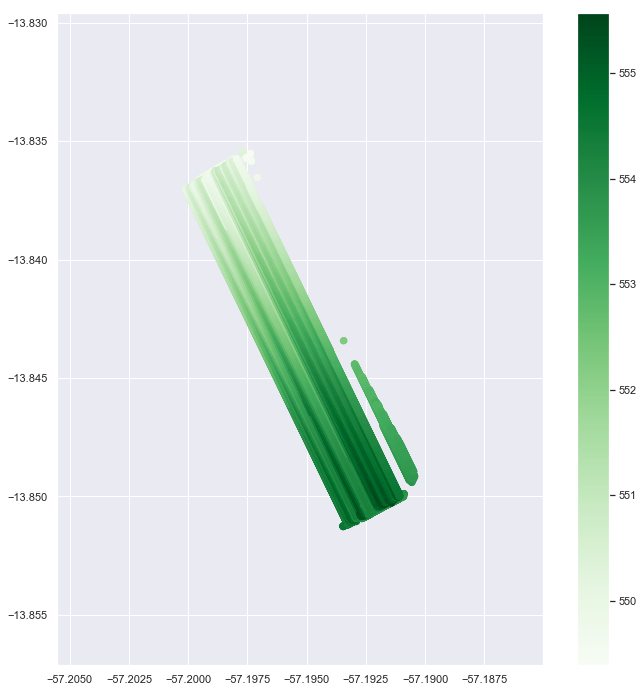

In [46]:
#Plots the differences in elevation among all points, but with different color scheme.
plot_attribute(data, 'Elevation', "Greens")

## HeatMap

In [47]:
df = below_3000[['Elevation', 'geometry']]
df = df.dropna()

points = df['geometry']
locations = pd.DataFrame(data= {'Latitude': points.x, 'Longitude': points.y})
weights = df['Elevation']

fig = gmaps.figure() 
heatmap_layer = gmaps.heatmap_layer(locations, weights=weights) 
fig.add_layer(gmaps.heatmap_layer(locations, weights=weights)) 
fig

Figure(layout=FigureLayout(height=u'420px'))

In [48]:
data.head()

,DISTANCE,SWATHWIDTH,VRYIELDBAL,SECTIONID,Crop,WetMass,Moisture,Time,Heading,VARIETY,Elevation,IsoTime,geometry
0,1.250782,1.524,4.811164,1458,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.19998886071195 -13.83705880575909 0)
1,1.250782,1.524,4.811164,1459,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.20000168781748 -13.83706453203675 0)
2,1.250782,1.524,4.811164,1460,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.20001451492361 -13.83707025831374 0)
3,1.270782,1.524,28.514902,1458,175,6208.245947,99.999992,8/8/2018 10:19:39 PM,156.418422,algodao,550.021629,2018-08-08T22:19:39.389Z,POINT Z (-57.19998405642441 -13.8370695107892 0)
4,1.270782,1.524,28.514902,1459,175,6208.245947,99.999992,8/8/2018 10:19:39 PM,156.418422,algodao,550.021629,2018-08-08T22:19:39.389Z,POINT Z (-57.19999698581748 -13.83707501303677 0)


## 6. Read Out the Data

In [49]:
#Set the file path and name
file_name = './data/data_filtered'

#Write out the file
clean_data.to_file(file_name)

In [50]:
def getx(pt):
    return pt.coords[0][0]

def gety(pt):
    return pt.coords[0][1]

lon = list(data.geometry.x)
lat = list(data.geometry.y)

In [ ]:
"""
Geometric example
------------------
A small example script showing the usage of the 'geographic' coordinates type
for ordinary kriging on a sphere.
"""

from pykrige.ok import OrdinaryKriging
import numpy as np

# Make this example reproducible:
np.random.seed(89239413)

# Generate random data following a uniform spatial distribution
# of nodes and a uniform distribution of values in the interval
# [2.0, 5.5]:
N = 7
lon = list(below_3000.geometry.x)
lat = list(below_3000.geometry.y)
z   = list(below_3000['WetMass'])

# Generate a regular grid with 60° longitude and 30° latitude steps:
grid_lon = np.linspace(-57.2050, -57.1875, 8)
grid_lat = np.linspace(-13.855, -13.830, 6)

# Create ordinary kriging object:
#OK = OrdinaryKriging(lon, lat, z, variogram_model='linear', verbose=False,
                     #enable_plotting=True, coordinates_type='geographic')

# Execute on grid:
#z1, ss1 = OK.execute('grid', grid_lon, grid_lat)

# Create ordinary kriging object ignoring curvature:
OK = OrdinaryKriging(lon, lat, z, variogram_model='linear', verbose=True,
                     enable_plotting=True)

# Execute on grid:
z2, ss2 = OK.execute('grid', grid_lon, grid_lat)

Plotting Enabled

Adjusting data for anisotropy...
Initializing variogram model...


In [10]:
#WetMass Statistics
data['WetMass'].describe()

count    154149.000000
mean       4055.639096
std        4313.584463
min          52.630958
25%        3555.152498
50%        3967.508454
75%        4373.136868
max      483374.696737
Name: WetMass, dtype: float64

In [11]:
data['VARIETY'].value_counts()

algodao    154149
Name: VARIETY, dtype: int64

In [12]:
data.geometry

0         POINT Z (-57.19998886071195 -13.83705880575909 0)
1         POINT Z (-57.20000168781748 -13.83706453203675 0)
2         POINT Z (-57.20001451492361 -13.83707025831374 0)
3          POINT Z (-57.19998405642441 -13.8370695107892 0)
4         POINT Z (-57.19999698581748 -13.83707501303677 0)
5         POINT Z (-57.20000991521115 -13.83708051528365 0)
6         POINT Z (-57.19997924005161 -13.83707971692051 0)
7         POINT Z (-57.19999213081748 -13.83708530503677 0)
8         POINT Z (-57.20000502158395 -13.83709089315233 0)
9         POINT Z (-57.19997442425005 -13.83709000669462 0)
10        POINT Z (-57.19998727781748 -13.83709567603676 0)
11        POINT Z (-57.20000013138552 -13.83710134537822 0)
12         POINT Z (-57.1999694821311 -13.83710014749397 0)
13        POINT Z (-57.19998226281748 -13.83710597203676 0)
14        POINT Z (-57.19999504350449 -13.83711179657887 0)
15        POINT Z (-57.19996463412441 -13.83711062777875 0)
16        POINT Z (-57.19997744481748 -1

In [13]:
type(data.geometry[0])

shapely.geometry.point.Point

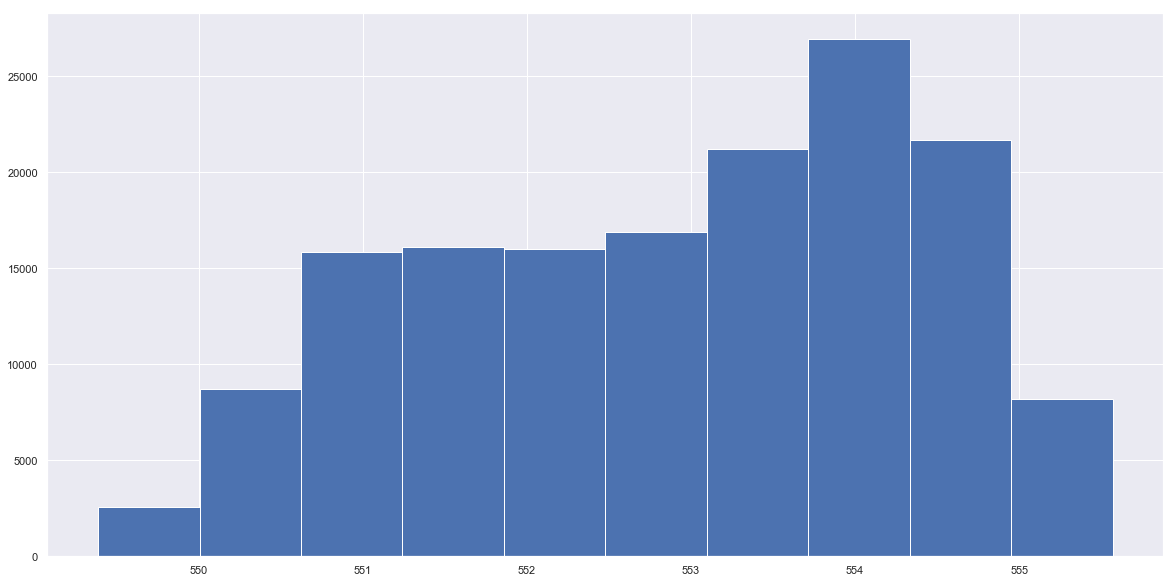

In [133]:
data['Elevation'].hist()

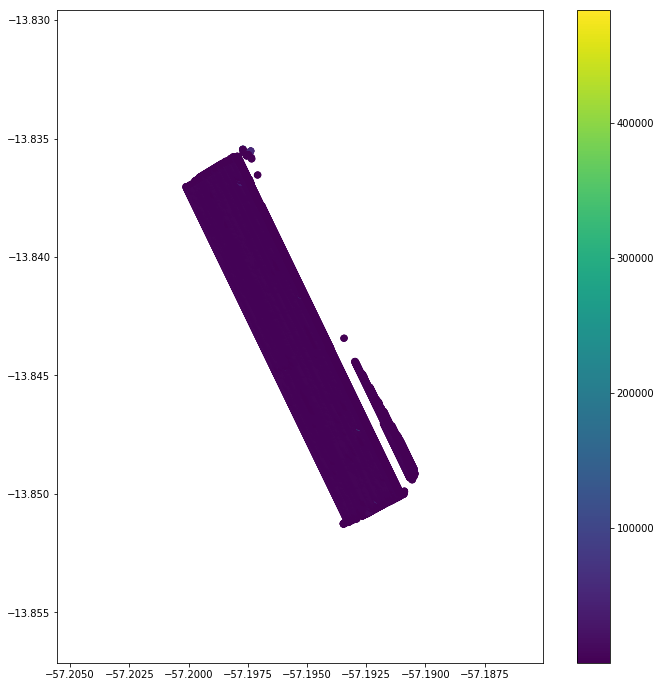

In [16]:
f, ax = plt.subplots(1, figsize=(12, 12))
ax=data.plot(ax=ax, column='WetMass', cmap="viridis", legend=True)
plt.show()

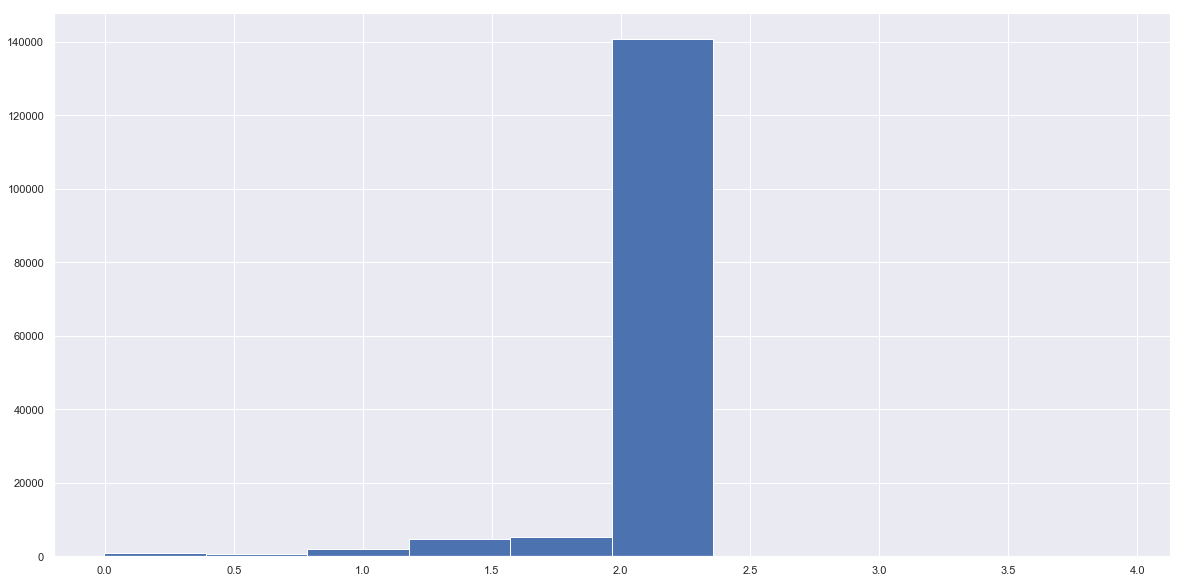

In [130]:
data['DISTANCE'].hist()

In [15]:
clean = data[data['WetMass'] < 8000]
clean.head()

,DISTANCE,SWATHWIDTH,VRYIELDBAL,SECTIONID,Crop,WetMass,Moisture,Time,Heading,VARIETY,Elevation,IsoTime,geometry
0,1.250782,1.524,4.811164,1458,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.19998886071195 -13.83705880575909 0)
1,1.250782,1.524,4.811164,1459,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.20000168781748 -13.83706453203675 0)
2,1.250782,1.524,4.811164,1460,175,1047.463809,99.999992,8/8/2018 10:19:38 PM,155.398422,algodao,549.994629,2018-08-08T22:19:38.400Z,POINT Z (-57.20001451492361 -13.83707025831374 0)
3,1.270782,1.524,28.514902,1458,175,6208.245947,99.999992,8/8/2018 10:19:39 PM,156.418422,algodao,550.021629,2018-08-08T22:19:39.389Z,POINT Z (-57.19998405642441 -13.8370695107892 0)
4,1.270782,1.524,28.514902,1459,175,6208.245947,99.999992,8/8/2018 10:19:39 PM,156.418422,algodao,550.021629,2018-08-08T22:19:39.389Z,POINT Z (-57.19999698581748 -13.83707501303677 0)


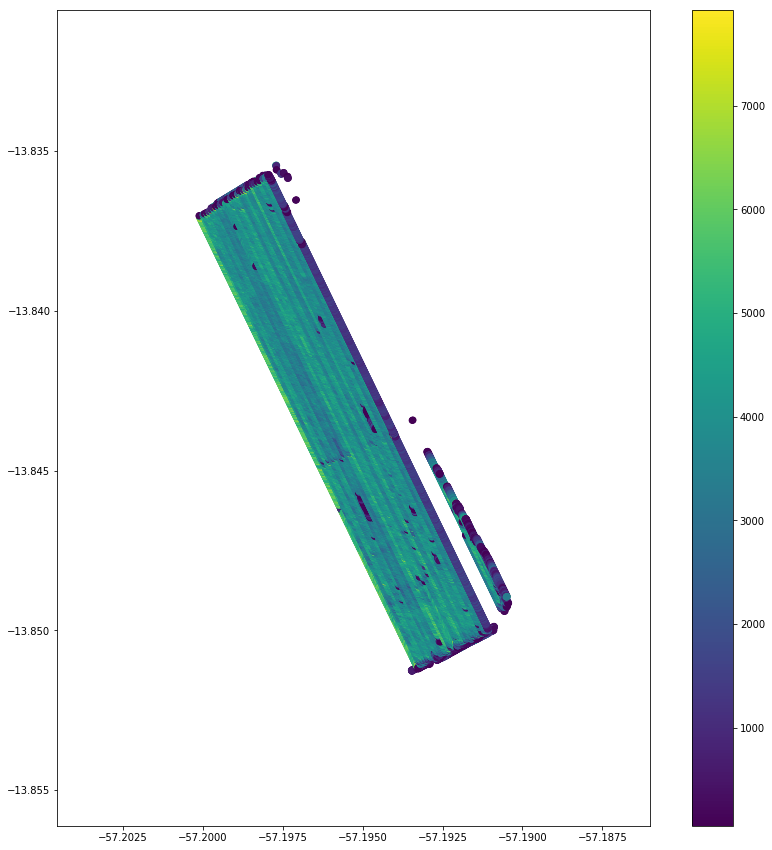

In [18]:
f, ax = plt.subplots(1, figsize=(15, 15))
ax=clean.plot(ax=ax, column='WetMass', cmap="viridis", legend=True)
plt.show()

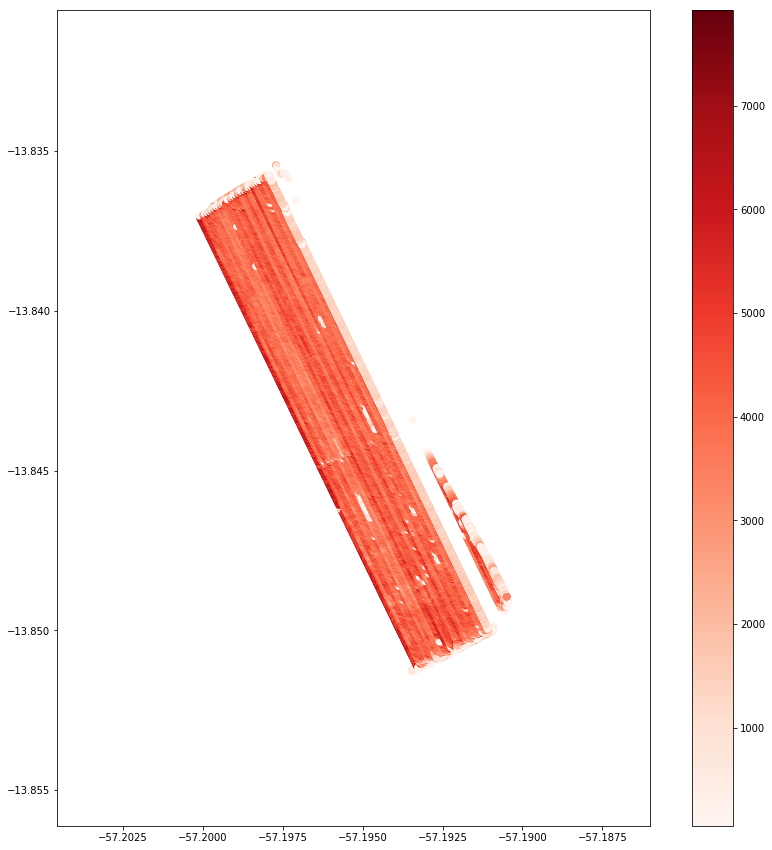

In [19]:
f, ax = plt.subplots(1, figsize=(15, 15))
ax=clean.plot(ax=ax, column='WetMass', cmap="Reds", legend=True)
plt.show()

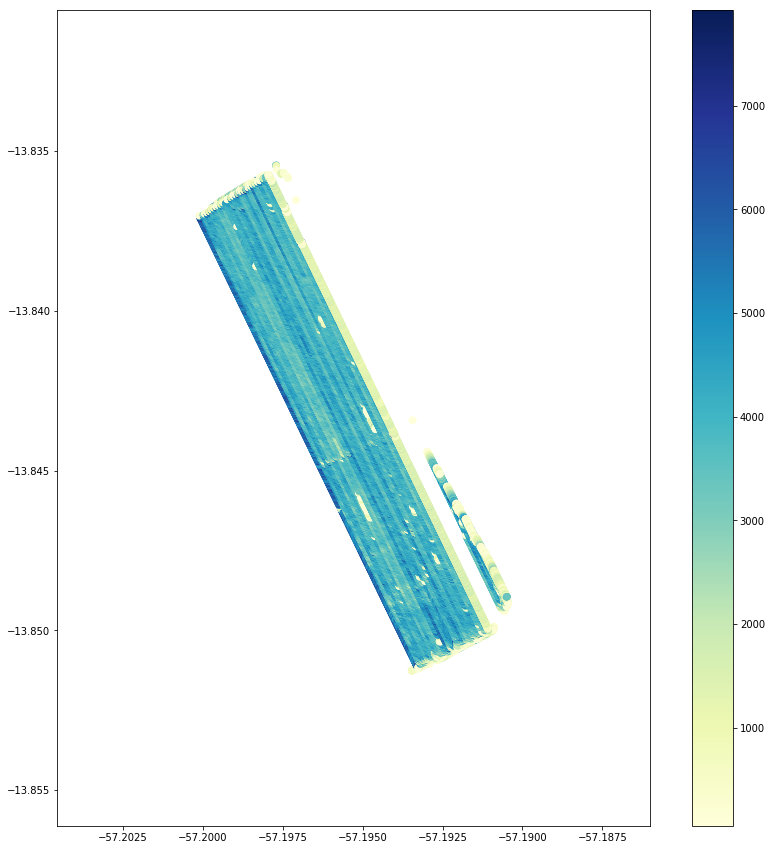

In [20]:
f, ax = plt.subplots(1, figsize=(15, 15))
ax=clean.plot(ax=ax, column='WetMass', cmap="YlGnBu", legend=True)
plt.show()

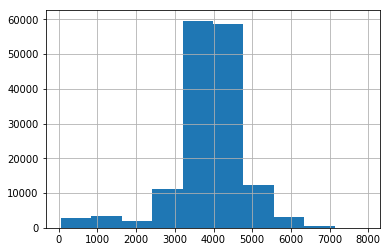

In [16]:
clean['WetMass'].hist()

In [17]:
#number of outliers (WetMass above 8000)
num = data.size - clean.size
perc = num // data.size
perc

0

In [49]:
import pykrige as pk
import pykrige.kriging_tools as kt

In [50]:
x = np.array(data['geometry'][:5000].apply(lambda p: p.x))
y = np.array(data['geometry'][:5000].apply(lambda p: p.y))

z = data['WetMass'][:5000]

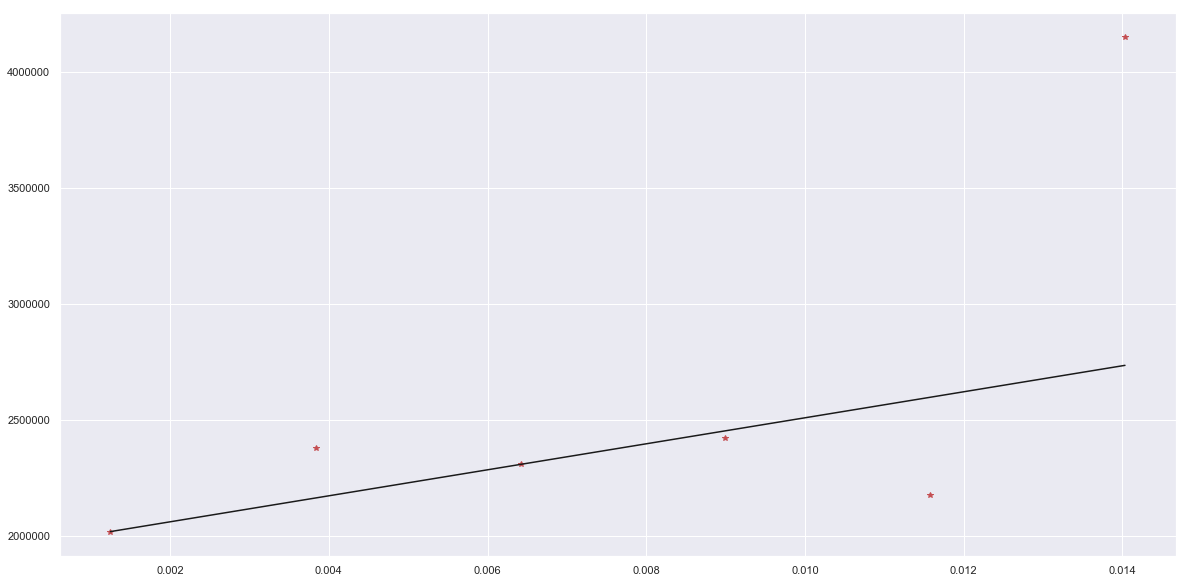

<pykrige.ok.OrdinaryKriging instance at 0x1a2312ecf8>

In [51]:
OK = pk.OrdinaryKriging(x, y, z, enable_plotting=True, coordinates_type='geographic')
OK

In [ ]:
z, ss = OK.execute('grid', x, y)

In [ ]:
data['IsoTime']

In [29]:
data['time'] = time
type(time[0])

datetime.datetime

In [ ]:
data

In [ ]:
data.shape